# Fashion-MNIST Classification with a Multi-Layer Perceptron

This notebook implements a fully connected neural network for image classification on the Fashion-MNIST dataset using Keras.

The main objectives of this project are:

- Load and explore the Fashion-MNIST dataset
- Preprocess grayscale images for a fully connected neural network
- Build a Multi-Layer Perceptron (MLP) classifier
- Apply dropout regularization
- Train the model using the Adam optimizer
- Evaluate classification performance
- Inspect correct and incorrect predictions
- Analyze per-class precision, recall, and F1-score
- Examine prediction errors using a confusion matrix

## 1. Importing Required Libraries

This section imports the libraries required for:

- Numerical computation
- Data manipulation
- Visualization
- Neural network construction
- Model training
- Classification evaluation

The neural network is implemented using Keras.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from keras.datasets import fashion_mnist
from keras.layers import Dense, Dropout, Activation
from keras.models import Sequential
from keras.utils import to_categorical
from keras.losses import CategoricalCrossentropy
from keras.optimizers import Adam
from keras import Input

from sklearn.metrics import classification_report, confusion_matrix

## 2. Loading the Fashion-MNIST Dataset

The Fashion-MNIST dataset is loaded directly from Keras.

The dataset contains grayscale images of clothing items belonging to 10 different classes.

Each image has a resolution of 28 × 28 pixels.

The dataset is divided into:

- 60,000 training images
- 10,000 test images

The original integer labels are retained for visualization and final evaluation.

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(f"train len : {X_train.shape}")
print(f"test len : {X_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train len : (60000, 28, 28)
test len : (10000, 28, 28)


## 3. Exploring the Dataset

Before preprocessing and training, one random example from each Fashion-MNIST class is visualized.

The 10 classes are:

- T-shirt/top
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot

This visualization provides an initial understanding of the appearance and similarity of the different clothing categories.

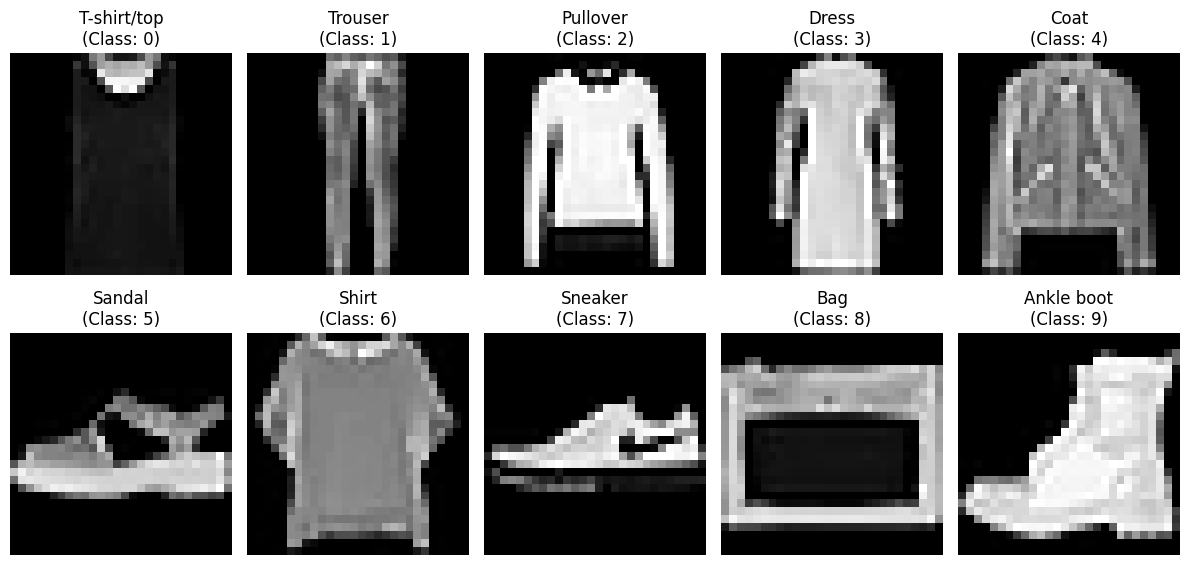

In [ ]:
class_labels_dict = {0:"T-shirt/top",1:"Trouser",2:"Pullover",3:"Dress",4:"Coat",5:"Sandal",6:"Shirt",7:"Sneaker",8:"Bag",9:"Ankle boot"}

num_classes = 10

random_images = []
random_labels = []

# For each class (0 through 9)
for class_label in range(num_classes):
    # Find indices of all images with this class label
    class_indices = np.where(y_train == class_label)[0]

    # Randomly select one index from these class indices
    random_index = np.random.choice(class_indices)

    # Store the image and its label
    random_images.append(X_train[random_index])
    random_labels.append(y_train[random_index])

fig = plt.figure(figsize=(12,6))

for i in range(num_classes):
    plt.subplot(2,5,i+1)
    img = random_images[i]
    plt.imshow(img, cmap='gray',aspect='equal', interpolation='none')
    plt.title(f"{class_labels_dict[random_labels[i]]}\n(Class: {random_labels[i]})")
    plt.axis('off')
plt.tight_layout()

## 4. Flattening the Input Images

A fully connected neural network expects each sample to be represented as a one-dimensional feature vector.

Each 28 × 28 image is therefore flattened into a vector containing 784 pixel values.

The resulting data shapes are:

- Training data: 60,000 × 784
- Test data: 10,000 × 784

In [7]:
X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)


print("Training matrix shape", X_train.shape)
print("Testing matrix shape", X_test.shape)

Training matrix shape (60000, 784)
Testing matrix shape (10000, 784)


## 5. Input Normalization

The image arrays are converted to `float32` before being passed to the neural network.

Fashion-MNIST pixel values originally lie in the range:

`[0, 255]`

The inputs are normalized to:

`[0, 1]`

by dividing each pixel value by 255.

Normalization improves numerical stability and makes optimization more effective during neural network training.

In [8]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

X_train = X_train/255
X_test = X_test/255

X_train.dtype, X_test.dtype

(dtype('float32'), dtype('float32'))

## 6. One-Hot Encoding the Class Labels

Fashion-MNIST contains 10 output classes.

The integer class labels are converted into one-hot encoded vectors using Keras `to_categorical`.

For example, class `9` is represented as:

`[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]`

This representation is required because the model uses a 10-neuron softmax output layer with categorical cross-entropy loss.

In [11]:
Y_train = to_categorical(y_train, num_classes)
Y_test = to_categorical(y_test, num_classes)

Y_train[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

## 7. Building the Multi-Layer Perceptron

A fully connected Multi-Layer Perceptron (MLP) is implemented using Keras.

The network receives a 784-dimensional flattened image as input.

The architecture contains:

- Dense layer with 512 neurons and ReLU activation
- Dropout with probability 0.2
- Dense layer with 256 neurons and ReLU activation
- Dropout with probability 0.2
- Dense layer with 128 neurons and ReLU activation
- Dropout with probability 0.2
- Dense layer with 64 neurons and ReLU activation
- Dropout with probability 0.2
- Output layer with 10 neurons and softmax activation

Dropout is used throughout the network to reduce overfitting.

In [14]:
model = Sequential([
    Input(shape=(784,)),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128),
    Activation('relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

## 8. Compiling the Model

The model is configured for multi-class classification.

The training configuration is:

- Loss function: Categorical Cross-Entropy
- Optimizer: Adam
- Learning rate: 0.001
- Evaluation metric: Accuracy

Categorical cross-entropy is appropriate because the target labels are represented using one-hot encoding.

In [20]:
model.compile(loss= CategoricalCrossentropy(),
              optimizer=Adam(learning_rate=0.001),
              metrics=["accuracy"],
              )

## 9. Training the Model

The MLP is trained for 30 epochs using mini-batches of 64 samples.

The training configuration is:

- Epochs: 30
- Batch size: 64
- Optimizer: Adam
- Learning rate: 0.001

The current notebook uses the Fashion-MNIST test set as `validation_data` during training.

Therefore, the values reported by Keras as `val_accuracy` and `val_loss` correspond to the test set rather than to an independent validation set.

For a stricter experimental setup, a separate validation subset should be created from the training data and the official test set should be reserved for final evaluation.

In [21]:
history = model.fit(X_train,
                    Y_train,
                    batch_size=64,
                    epochs=30,
                    validation_data=(X_test,Y_test))


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6992 - loss: 0.8512 - val_accuracy: 0.8380 - val_loss: 0.4539
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8429 - loss: 0.4409 - val_accuracy: 0.8498 - val_loss: 0.4085
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8581 - loss: 0.3998 - val_accuracy: 0.8655 - val_loss: 0.3747
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8662 - loss: 0.3724 - val_accuracy: 0.8659 - val_loss: 0.3808
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8767 - loss: 0.3480 - val_accuracy: 0.8734 - val_loss: 0.3566
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8757 - loss: 0.3393 - val_accuracy: 0.8678 - val_loss: 0.3753
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8822 - loss: 0.3274 - val_accuracy: 0.8775 - val_loss: 0.3440
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8861 - loss: 0.3163 - val_accuracy: 0

## 10. Training Performance Analysis

The training and monitored test-set accuracy are plotted across all epochs.

This visualization helps analyze:

- Model convergence
- Generalization behavior
- The difference between training and test performance
- Possible signs of overfitting

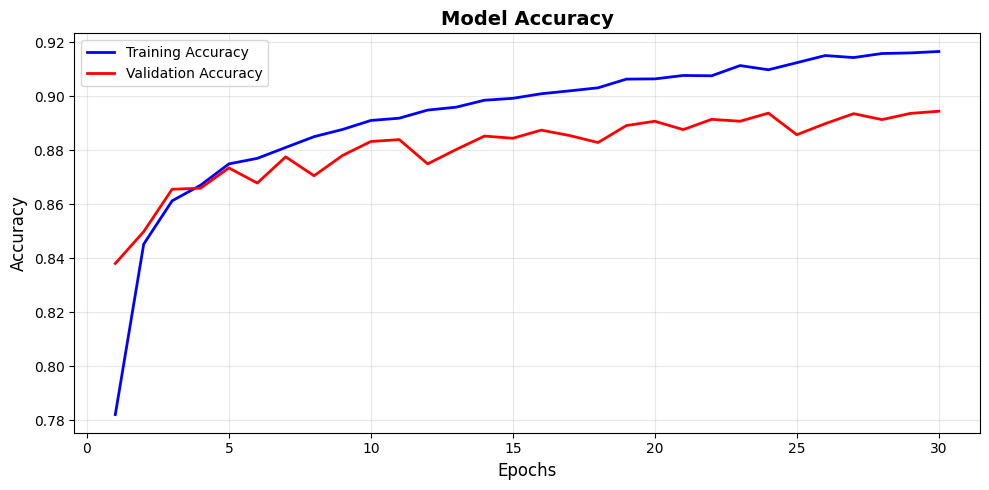

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, acc, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 10.1 Best Recorded Accuracy

The highest monitored accuracy is identified from the values recorded during training.

In the saved notebook run, the highest monitored accuracy is approximately 89.44%, achieved at epoch 30.

Because the test set is currently used as `validation_data`, this value corresponds to test-set monitoring rather than an independent validation score.

In [24]:
best_val_epoch = np.array(val_acc).argmax()
best_val_acc = val_acc[best_val_epoch]

print(f'Best validation accuracy is : {best_val_acc} at step : {best_val_epoch+1}')

Best validation accuracy is : 0.8944000005722046 at step : 30


## 11. Inspecting Model Predictions

Individual predictions are inspected to better understand the behavior of the trained classifier.

First, randomly selected correctly classified test images are displayed together with:

- Predicted class
- Actual class

This provides a qualitative view of successful model predictions.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


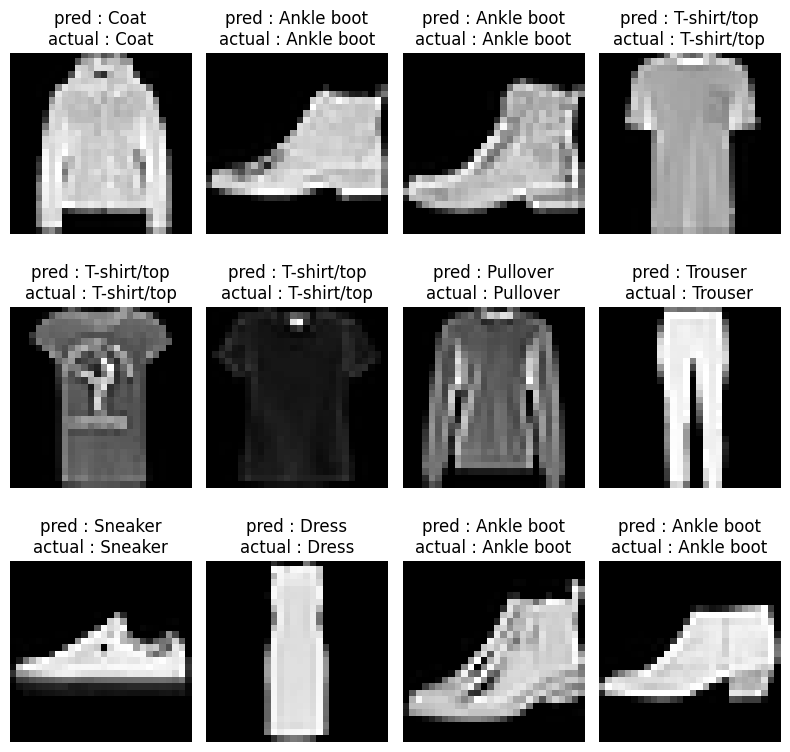

In [33]:
y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

correct_pred = np.where(y_pred == y_test)[0]
random_corrects = np.random.choice(correct_pred, 12)

plt.figure(figsize=(8,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[random_corrects[i]].reshape(28,28), cmap='gray',aspect='equal', interpolation='none')
    plt.title(f"pred : {class_labels_dict[y_pred[random_corrects[i]]]}\nactual : {class_labels_dict[y_test[random_corrects[i]]]}")
    plt.axis('off')
plt.tight_layout()


### 11.1 Inspecting Misclassified Samples

Randomly selected misclassified test images are visualized together with their predicted and actual labels.

Examining incorrect predictions helps identify classes that are visually similar and therefore more difficult for the MLP to distinguish.

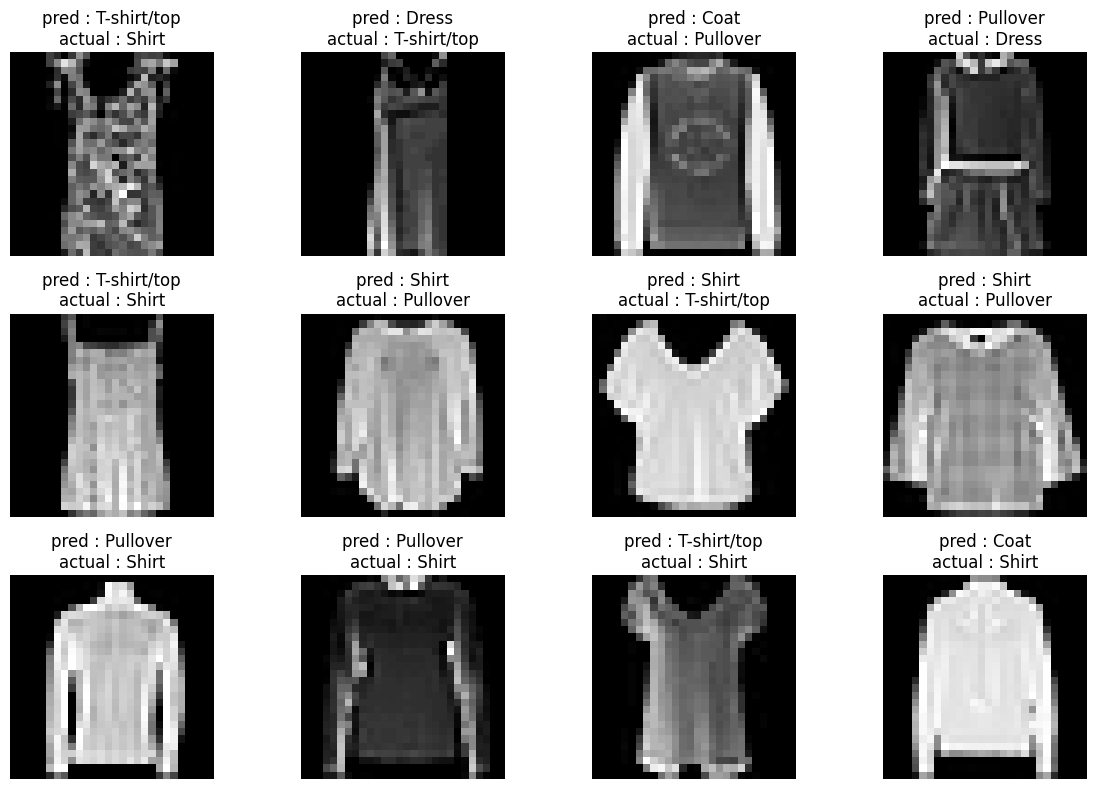

In [35]:
incorrect_pred = np.where(y_pred != y_test)[0]
random_incorrects = np.random.choice(incorrect_pred, 12)

plt.figure(figsize=(12,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[random_incorrects[i]].reshape(28,28), cmap='gray',aspect='equal', interpolation='none')
    plt.title(f"pred : {class_labels_dict[y_pred[random_incorrects[i]]]}\nactual : {class_labels_dict[y_test[random_incorrects[i]]]}")
    plt.axis('off')
plt.tight_layout()


## 12. Class-Level Performance Evaluation

The model is evaluated using Scikit-learn's `classification_report`.

For every Fashion-MNIST class, the following metrics are reported:

- Precision
- Recall
- F1-score
- Support

The report provides a more detailed view of model performance than overall accuracy alone.

In [36]:
print(classification_report(y_test, y_pred, target_names=class_labels_dict.values()))

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.84      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.76      0.85      0.81      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.78      0.82      0.80      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.76      0.67      0.72      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



## 13. Confusion Matrix

A confusion matrix is calculated to analyze the relationship between predicted and actual classes.

The matrix helps identify systematic classification errors and shows which Fashion-MNIST categories are most frequently confused with one another.

This is particularly useful for visually similar classes such as:

- T-shirt/top
- Shirt
- Pullover
- Coat

In [37]:
matrix = pd.DataFrame(confusion_matrix(y_test, y_pred), index=class_labels_dict.values(), columns=class_labels_dict.values())
matrix.index.name = 'predict'
matrix.columns.name = 'actual'

matrix

actual,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
predict,,,,,,,,,,
T-shirt/top,843,1,18,21,5,1,107,0,4,0
Trouser,1,980,2,12,3,0,1,0,1,0
Pullover,15,1,855,8,77,0,42,0,2,0
Dress,14,3,17,892,51,0,19,0,4,0
Coat,1,1,127,20,822,0,28,0,1,0
Sandal,0,0,0,0,0,977,0,17,1,5
Shirt,108,1,99,21,91,0,673,0,7,0
Sneaker,0,0,0,0,0,7,0,969,0,24
Bag,3,0,1,6,2,3,9,4,972,0


## 14. Conclusion

This notebook implemented a Multi-Layer Perceptron for Fashion-MNIST image classification.

The workflow included:

- Dataset loading and visualization
- Image flattening and normalization
- One-hot encoding
- MLP construction with dropout regularization
- Training with the Adam optimizer
- Accuracy analysis
- Prediction inspection
- Per-class evaluation
- Confusion matrix analysis

In the saved experiment, the model achieved approximately 89% overall classification accuracy.

The results also show that visually similar clothing categories are more difficult to distinguish. In particular, the `Shirt` class obtained lower recall than several other classes.

A natural next step would be to compare this fully connected network with a Convolutional Neural Network (CNN), which can preserve and exploit the spatial structure of the original 28 × 28 images.